In [1]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)

path = "/home/students/studweilc1/MU-Diff/"
# add this to path for imports
if path not in sys.path:
    sys.path.append(path)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import monai
import math
import pandas as pd
from monai.metrics import DiceMetric
from monai.networks.blocks import Warp 
from monai.losses import LocalNormalizedCrossCorrelationLoss, BendingEnergyLoss
SPATIAL_DIMS = 2
# Let's assume you have 3 moving channels (e.g., T1, BOLD, Diffusion)
# and 1 fixed channel.
MOVING_CHANNELS = 3
FIXED_CHANNELS = 1
IN_CHANNELS = MOVING_CHANNELS + FIXED_CHANNELS # Total input channels for U-Net
OUT_CHANNELS = SPATIAL_DIMS # U-Net outputs a 2-channel DDF for 2D images


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [3]:
from reg_u_net import RegistrationUNet, SpatialTransformer
from reg_u_net_single import RegistrationUNet as RegistrationUNetSingle
from reg_u_net_single import SpatialTransformer as SpatialTransformerSingle

from dataset.dataset_dixon import CreateDatasetSynthesis_with_masks, CreateDatasetSynthetic

## Data Loaders

In [4]:
input_path = "../data/my_data2"
batch_size = 1
dataset = CreateDatasetSynthesis_with_masks(phase="train", input_path=input_path)
dataset_val = CreateDatasetSynthesis_with_masks(phase="val", input_path=input_path)

data_loader = torch.utils.data.DataLoader(dataset,
                                            batch_size=batch_size,
                                            shuffle=False,
                                            num_workers=1,
                                            pin_memory=False,
                                            drop_last=True)

data_loader_val = torch.utils.data.DataLoader(dataset_val,
                                                batch_size=batch_size,
                                                shuffle=False,
                                                num_workers=1,
                                                pin_memory=False,
                                                drop_last=True)

padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0


In [57]:
input_path_synth = "../data/synthetic/exp_brats2"
input_path = "../data/my_data2"
batch_size = 1
dataset_single = CreateDatasetSynthetic(phase="train", input_path_org=input_path, input_path_synthetic=input_path_synth)
dataset_val_single = CreateDatasetSynthetic(phase="val", input_path_org=input_path, input_path_synthetic=input_path_synth)

data_loader_single = torch.utils.data.DataLoader(dataset_single,
                                            batch_size=batch_size,
                                            shuffle=False,
                                            num_workers=1,
                                            pin_memory=False,
                                            drop_last=True)

data_loader_val_single = torch.utils.data.DataLoader(dataset_val_single,
                                                batch_size=batch_size,
                                                shuffle=False,
                                                num_workers=1,
                                                pin_memory=False,
                                                drop_last=True)

padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0
padding in x-y with:0-0


In [30]:
for i , data in enumerate(data_loader_single):
    x_synth, x_tgt, m1, m2, m3, m_tgt = data
    break

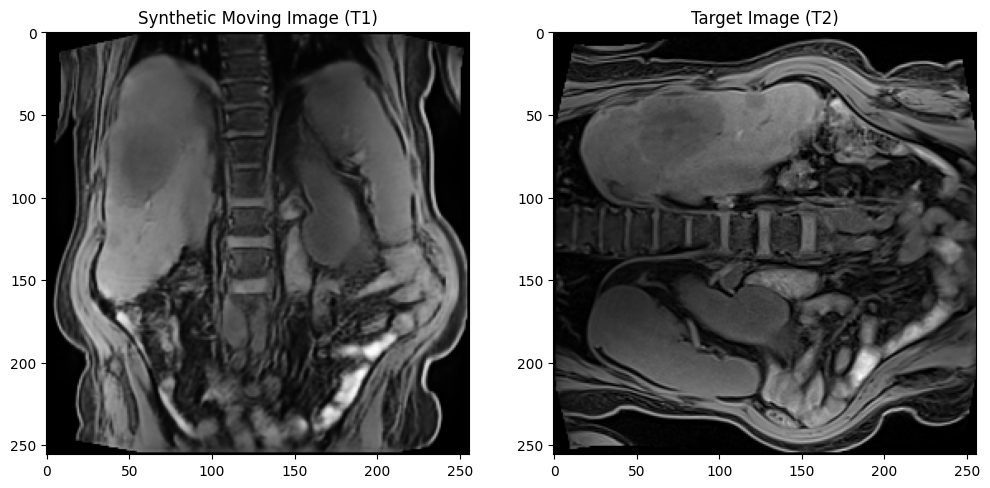

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
ax[0].imshow(x_synth[0, 0], cmap='gray')
ax[0].set_title('Synthetic Moving Image (T1)')
ax[1].imshow(x_tgt[0, 0], cmap='gray')
ax[1].set_title('Target Image (T2)')
plt.show()

## Training

In [6]:
device = torch.device("cpu")
model = RegistrationUNet().to(device)
spatial_transformer = SpatialTransformer(size=(256, 256)).to(device) 
similarity_loss = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2)
smoothing_loss = monai.losses.BendingEnergyLoss()
lambda_weight = 0.5
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
lambda_regularization = 0.5

In [7]:
def validate_model(model, loader, device, spatial_transformer, similarity_loss, smoothing_loss, lambda_regularization):
    """Run a validation epoch with the updated model that only predicts flows."""
    model.eval()  # Set model to evaluation mode
    val_loss = 0
    with torch.no_grad():  # Do not calculate gradients
        for x1, x2, x3, x4, m1, m2, m3, m4 in loader:
            # 1. Prepare moving and fixed images
            moving_images = torch.cat([x1, x2, x3], dim=1).to(device)
            fixed_image = x4.to(device)

            # 2. Create the single input tensor for the U-Net
            model_input = torch.cat([moving_images, fixed_image], dim=1)
            
            # 3. Get the tuple of three flow fields from the model
            flow1, flow2, flow3 = model(model_input)

            # 4. Explicitly warp each moving image with its corresponding flow
            moving1, moving2, moving3 = torch.chunk(moving_images, 3, dim=1)
            warped1 = spatial_transformer(moving1, flow1)
            warped2 = spatial_transformer(moving2, flow2)
            warped3 = spatial_transformer(moving3, flow3)
            warped_images = torch.cat([warped1, warped2, warped3], dim=1)

            # 5. Calculate similarity loss (this logic remains the same)
            loss_sim_1 = similarity_loss(warped_images[:, 0:1, ...], fixed_image)
            loss_sim_2 = similarity_loss(warped_images[:, 1:2, ...], fixed_image)
            loss_sim_3 = similarity_loss(warped_images[:, 2:3, ...], fixed_image)
            loss_sim = (loss_sim_1 + loss_sim_2 + loss_sim_3) / 3

            # 6. Calculate smoothing loss for each DDF and average them
            loss_reg = (smoothing_loss(flow1) + smoothing_loss(flow2) + smoothing_loss(flow3)) / 3
            
            total_loss = loss_sim + lambda_regularization * loss_reg
            val_loss += total_loss.item()
    
    avg_loss = val_loss / len(loader)
    return avg_loss

In [57]:
num_epochs = 1
best_val_loss = float('inf')
for epoch in range(num_epochs):
    print(f"--- Epoch {epoch+1}/{num_epochs} ---")
    model.train() # Set model to training mode
    train_loss = 0

    for iteration, (x1, x2, x3, x4, m1, m2, m3, m4) in enumerate(data_loader):
        moving_images = torch.cat([x1, x2, x3], dim=1).to(device)
        fixed_image = x4.to(device)
        optimizer.zero_grad()
        # Create the single input tensor for the model
        model_input = torch.cat([moving_images, fixed_image], dim=1)
        
        # Get the tuple of flow fields from the model
        flow1, flow2, flow3 = model(model_input)
        
        # Apply the transformation explicitly using the transformer
        moving1, moving2, moving3 = torch.chunk(moving_images, 3, dim=1)
        warped1 = spatial_transformer(moving1, flow1)
        warped2 = spatial_transformer(moving2, flow2)
        warped3 = spatial_transformer(moving3, flow3)
        warped_images = torch.cat([warped1, warped2, warped3], dim=1)
        # --- Loss calculation ---
        # Similarity loss (this part is the same as your code)
        loss_sim_1 = similarity_loss(warped_images[:, 0:1, ...], fixed_image)
        loss_sim_2 = similarity_loss(warped_images[:, 1:2, ...], fixed_image)
        loss_sim_3 = similarity_loss(warped_images[:, 2:3, ...], fixed_image)
        loss_sim = (loss_sim_1 + loss_sim_2 + loss_sim_3) / 3
        loss_reg = (smoothing_loss(flow1) + smoothing_loss(flow2) + smoothing_loss(flow3)) / 3
        total_loss = loss_sim + lambda_regularization * loss_reg
        total_loss.backward()
        optimizer.step()
        train_loss += total_loss.item()

    avg_train_loss = train_loss / len(data_loader)
    avg_val_loss = validate_model(
                    model, 
                    data_loader_val, 
                    device, 
                    spatial_transformer, 
                    similarity_loss, 
                    smoothing_loss, 
                    lambda_regularization
                    )
    
    print(f"Epoch {epoch+1} Avg Train Loss: {avg_train_loss:.4f}, Avg Validation Loss: {avg_val_loss:.4f}")

    # Save the model if validation loss has improved
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_registration_model.pth")
        print("   -> Saved new best model.")

print("\n--- Training finished ---")

--- Epoch 1/1 ---
Epoch 1 Avg Train Loss: -0.3548, Avg Validation Loss: -0.3683
   -> Saved new best model.

--- Training finished ---


## Visualize Functions

In [8]:
def visualize_results(model, loader, device, num_samples=1):
    """Visualize registration results, masks, and Dice scores before and after warping."""
    model.eval()
    dice_metric = DiceMetric(include_background=True, reduction="mean")
    # We need to instantiate the transformer to apply the predicted flows
    spatial_transformer = SpatialTransformer(size=(256, 256)).to(device)
    
    # Get a single batch of validation data
    for iteration, (x1, x2, x3, x4, m1, m2, m3, m4) in enumerate(loader):
        if iteration >= num_samples:
            break
        
        # Prepare data and move to the selected device
        moving_images = torch.cat([x1, x2, x3], dim=1).to(device)
        moving_masks = torch.cat([m1, m2, m3], dim=1).to(device)
        fixed_image = x4.to(device)
        fixed_mask = m4.to(device)
        
        # Perform inference
        with torch.no_grad():
            # Create the single input tensor for the U-Net
            model_input = torch.cat([moving_images, fixed_image], dim=1)
            
            # Get the tuple of three flow fields from the model
            flow1, flow2, flow3 = model(model_input)
            
            # Explicitly warp each moving image and mask with its corresponding flow
            moving1_img, moving2_img, moving3_img = torch.chunk(moving_images, 3, dim=1)
            moving1_mask, moving2_mask, moving3_mask = torch.chunk(moving_masks, 3, dim=1)

            warped1_img = spatial_transformer(moving1_img, flow1)
            warped2_img = spatial_transformer(moving2_img, flow2)
            warped3_img = spatial_transformer(moving3_img, flow3)
            warped_images = torch.cat([warped1_img, warped2_img, warped3_img], dim=1)
            
            warped1_mask = spatial_transformer(moving1_mask, flow1)
            warped2_mask = spatial_transformer(moving2_mask, flow2)
            warped3_mask = spatial_transformer(moving3_mask, flow3)
            warped_masks = torch.cat([warped1_mask, warped2_mask, warped3_mask], dim=1)

        # Prepare for plotting (select first item in batch and move to CPU)
        moving_images_np = moving_images[0].cpu().numpy()
        warped_images_np = warped_images[0].cpu().numpy()
        fixed_image_np = fixed_image[0, 0].cpu().numpy()
        
        moving_masks_np = moving_masks[0].cpu().numpy()
        warped_masks_np = warped_masks[0].cpu().numpy()
        fixed_mask_np = fixed_mask[0, 0].cpu().numpy()

        # Create the plot
        fig, axes = plt.subplots(3, 4, figsize=(20, 15))
        fig.suptitle('Registration Results for All Channels', fontsize=20)

        for i in range(3): # Iterate through the 3 moving channels
            # --- DICE SCORE CALCULATION (using tensors on device) ---
            # Select tensors for the i-th channel (first item in batch)
            # MONAI DiceMetric expects shape [B, C, H, W]
            moving_mask_i = moving_masks[0:1, i:i+1, ...]
            warped_mask_i = warped_masks[0:1, i:i+1, ...]
            fixed_mask_i = fixed_mask[0:1, ...]

            # Binarize masks for Dice calculation
            moving_mask_bin = (moving_mask_i > 0.5).float()
            warped_mask_bin = (warped_mask_i > 0.5).float()
            fixed_mask_bin = (fixed_mask_i > 0.5).float()

            # Calculate initial Dice score (moving vs fixed)
            dice_metric(y_pred=moving_mask_bin, y=fixed_mask_bin)
            initial_dice_score = dice_metric.aggregate().item()
            dice_metric.reset()

            # Calculate warped Dice score (warped vs fixed) - THIS IS THE FIX
            dice_metric(y_pred=warped_mask_bin, y=fixed_mask_bin)
            warped_dice_score = dice_metric.aggregate().item()
            dice_metric.reset()

            # --- PLOTTING ---
            # Column 1: Moving Image + Mask
            ax = axes[i, 0]
            ax.imshow(moving_images_np[i], cmap='gray')
            ax.imshow(np.ma.masked_where(moving_masks_np[i] < 0.5, moving_masks_np[i]), cmap='cool', alpha=0.5)
            ax.set_title(f'Moving Channel {i+1}\nInitial Dice: {initial_dice_score:.4f}')
            ax.axis('off')

            # Column 2: Warped Image + Mask
            ax = axes[i, 1]
            ax.imshow(warped_images_np[i], cmap='gray')
            ax.imshow(np.ma.masked_where(warped_masks_np[i] < 0.5, warped_masks_np[i]), cmap='cool', alpha=0.5)
            ax.set_title(f'Warped Channel {i+1}\nWarped Dice: {warped_dice_score:.4f}')
            ax.axis('off')

            # Column 3: Fixed Image + Mask
            ax = axes[i, 2]
            ax.imshow(fixed_image_np, cmap='gray')
            ax.imshow(np.ma.masked_where(fixed_mask_np < 0.5, fixed_mask_np), cmap='cool', alpha=0.5)
            ax.set_title(f'Fixed Image')
            ax.axis('off')

            # Column 4: Difference Image (Warped - Fixed)
            ax = axes[i, 3]
            diff_img = np.abs(warped_images_np[i] - fixed_image_np)
            im = ax.imshow(diff_img, cmap='hot')
            ax.set_title(f'Difference')
            ax.axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

In [28]:
@torch.no_grad()
def visualize_results_single(model, loader, device, num_samples=1):
    """
    Visualize registration results for the new synthetic->target setup.
    For each sample (up to num_samples):
      - shows moving (synthetic) image+mask, warped image+mask, fixed (target) image+mask, and |warped - fixed|
      - prints/plots Dice before and after warping for each of m1, m2, m3 vs m_target
    """
    model.eval()
    dice_metric = DiceMetric(include_background=True, reduction="mean")
    similarity_loss = LocalNormalizedCrossCorrelationLoss(spatial_dims=2)

    # Iterate over up to `num_samples` batches (each visualization uses the first item in the batch)
    for iteration, (x_synth, x_tgt, m1, m2, m3, m_tgt) in enumerate(loader):
        if iteration >= num_samples:
            break

        # Move to device
        x_synth = x_synth.to(device)   # (B,1,H,W)
        x_tgt   = x_tgt.to(device)     # (B,1,H,W)
        m1      = m1.to(device)        # (B,1,H,W)
        m2      = m2.to(device)        # (B,1,H,W)
        m3      = m3.to(device)        # (B,1,H,W)
        m_tgt   = m_tgt.to(device)     # (B,1,H,W)

        # Build transformers sized to the data (derive H,W from tensors)
        _, _, H, W = x_synth.shape
        img_st  = SpatialTransformerSingle(size=(H, W), mode='bilinear').to(device)
        mask_st = SpatialTransformerSingle(size=(H, W), mode='nearest').to(device)

        # Forward: single flow from synthetic+target
        model_input = torch.cat([x_synth, x_tgt], dim=1)   # (B,2,H,W)
        flow = model(model_input)                          # (B,2,H,W)

        # Warp image and masks
        x_synth_warped = img_st(x_synth, flow)             # bilinear
        m1_w = mask_st(m1, flow)                           # nearest
        m2_w = mask_st(m2, flow)
        m3_w = mask_st(m3, flow)

        # Numpy views for plotting (take the first item in batch)
        synth_np      = x_synth[0, 0].detach().cpu().numpy()
        synth_w_np    = x_synth_warped[0, 0].detach().cpu().numpy()
        tgt_np        = x_tgt[0, 0].detach().cpu().numpy()
        mt_np         = m_tgt[0, 0].detach().cpu().numpy()
        m_list_np     = [m1[0, 0].detach().cpu().numpy(),
                         m2[0, 0].detach().cpu().numpy(),
                         m3[0, 0].detach().cpu().numpy()]
        mw_list_np    = [m1_w[0, 0].detach().cpu().numpy(),
                         m2_w[0, 0].detach().cpu().numpy(),
                         m3_w[0, 0].detach().cpu().numpy()]
        
        # compute loss_sim similarity_loss
        loss_sim_warped = similarity_loss(x_synth_warped, x_tgt)
        loss_sim_unwarped = similarity_loss(x_synth, x_tgt)
        loss_sim_perfect = similarity_loss(x_tgt, x_tgt)
        print(f"[Sample {iteration+1}] Similarity Loss | Unwarped: {loss_sim_unwarped.item():.4f} | Warped: {loss_sim_warped.item():.4f} | Perfect: {loss_sim_perfect.item():.4f}")


        # Compute Dice (per mask) for the first item in the batch
        # MONAI DiceMetric expects [B, C, H, W]
        def dice_pair(pred, target):
            dice_metric(y_pred=(pred > 0.5).float(), y=(target > 0.5).float())
            d = dice_metric.aggregate().item()
            dice_metric.reset()
            return d

        initial_dice = []
        warped_dice  = []
        for mw, m in zip([m1_w, m2_w, m3_w], [m1, m2, m3]):
            # Use the first sample in the batch
            m0     = m[0:1, ...]
            mw0    = mw[0:1, ...]
            mt0    = m_tgt[0:1, ...]
            initial_dice.append(dice_pair(m0,  mt0))
            warped_dice.append( dice_pair(mw0, mt0))

        # Plot: 3 rows (one per moving mask), 4 columns like before
        fig, axes = plt.subplots(3, 4, figsize=(20, 15))
        fig.suptitle('Registration Results (Synthetic → Target)', fontsize=20)

        for i in range(3):
            # Column 1: Moving (synthetic) image + moving mask i
            ax = axes[i, 0]
            ax.imshow(synth_np, cmap='gray')
            ax.imshow(np.ma.masked_where(m_list_np[i] < 0.5, m_list_np[i]), cmap='cool', alpha=0.5)
            ax.set_title(f'Moving (Synth) + m{i+1}\nInitial Dice (m{i+1}→mt): {initial_dice[i]:.4f}')
            ax.axis('off')

            # Column 2: Warped synthetic + warped mask i
            ax = axes[i, 1]
            ax.imshow(synth_w_np, cmap='gray')
            ax.imshow(np.ma.masked_where(mw_list_np[i] < 0.5, mw_list_np[i]), cmap='cool', alpha=0.5)
            ax.set_title(f'Warped + m{i+1}_warped\nWarped Dice (m{i+1}_w→mt): {warped_dice[i]:.4f}')
            ax.axis('off')

            # Column 3: Fixed (target) image + target mask
            ax = axes[i, 2]
            ax.imshow(tgt_np, cmap='gray')
            ax.imshow(np.ma.masked_where(mt_np < 0.5, mt_np), cmap='cool', alpha=0.5)
            ax.set_title('Fixed (Target) + m_target')
            ax.axis('off')

            # Column 4: |Warped - Fixed| (images)
            ax = axes[i, 3]
            diff_img = np.abs(synth_w_np - tgt_np)
            ax.imshow(diff_img, cmap='hot')
            ax.set_title('Difference |Warped - Fixed|')
            ax.axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # Also print per-mask Dice in the console for clarity
        for i in range(3):
            print(f"[Sample {iteration+1}] m{i+1}→m_target | Initial Dice: {initial_dice[i]:.4f} | Warped Dice: {warped_dice[i]:.4f}")


## Visualize

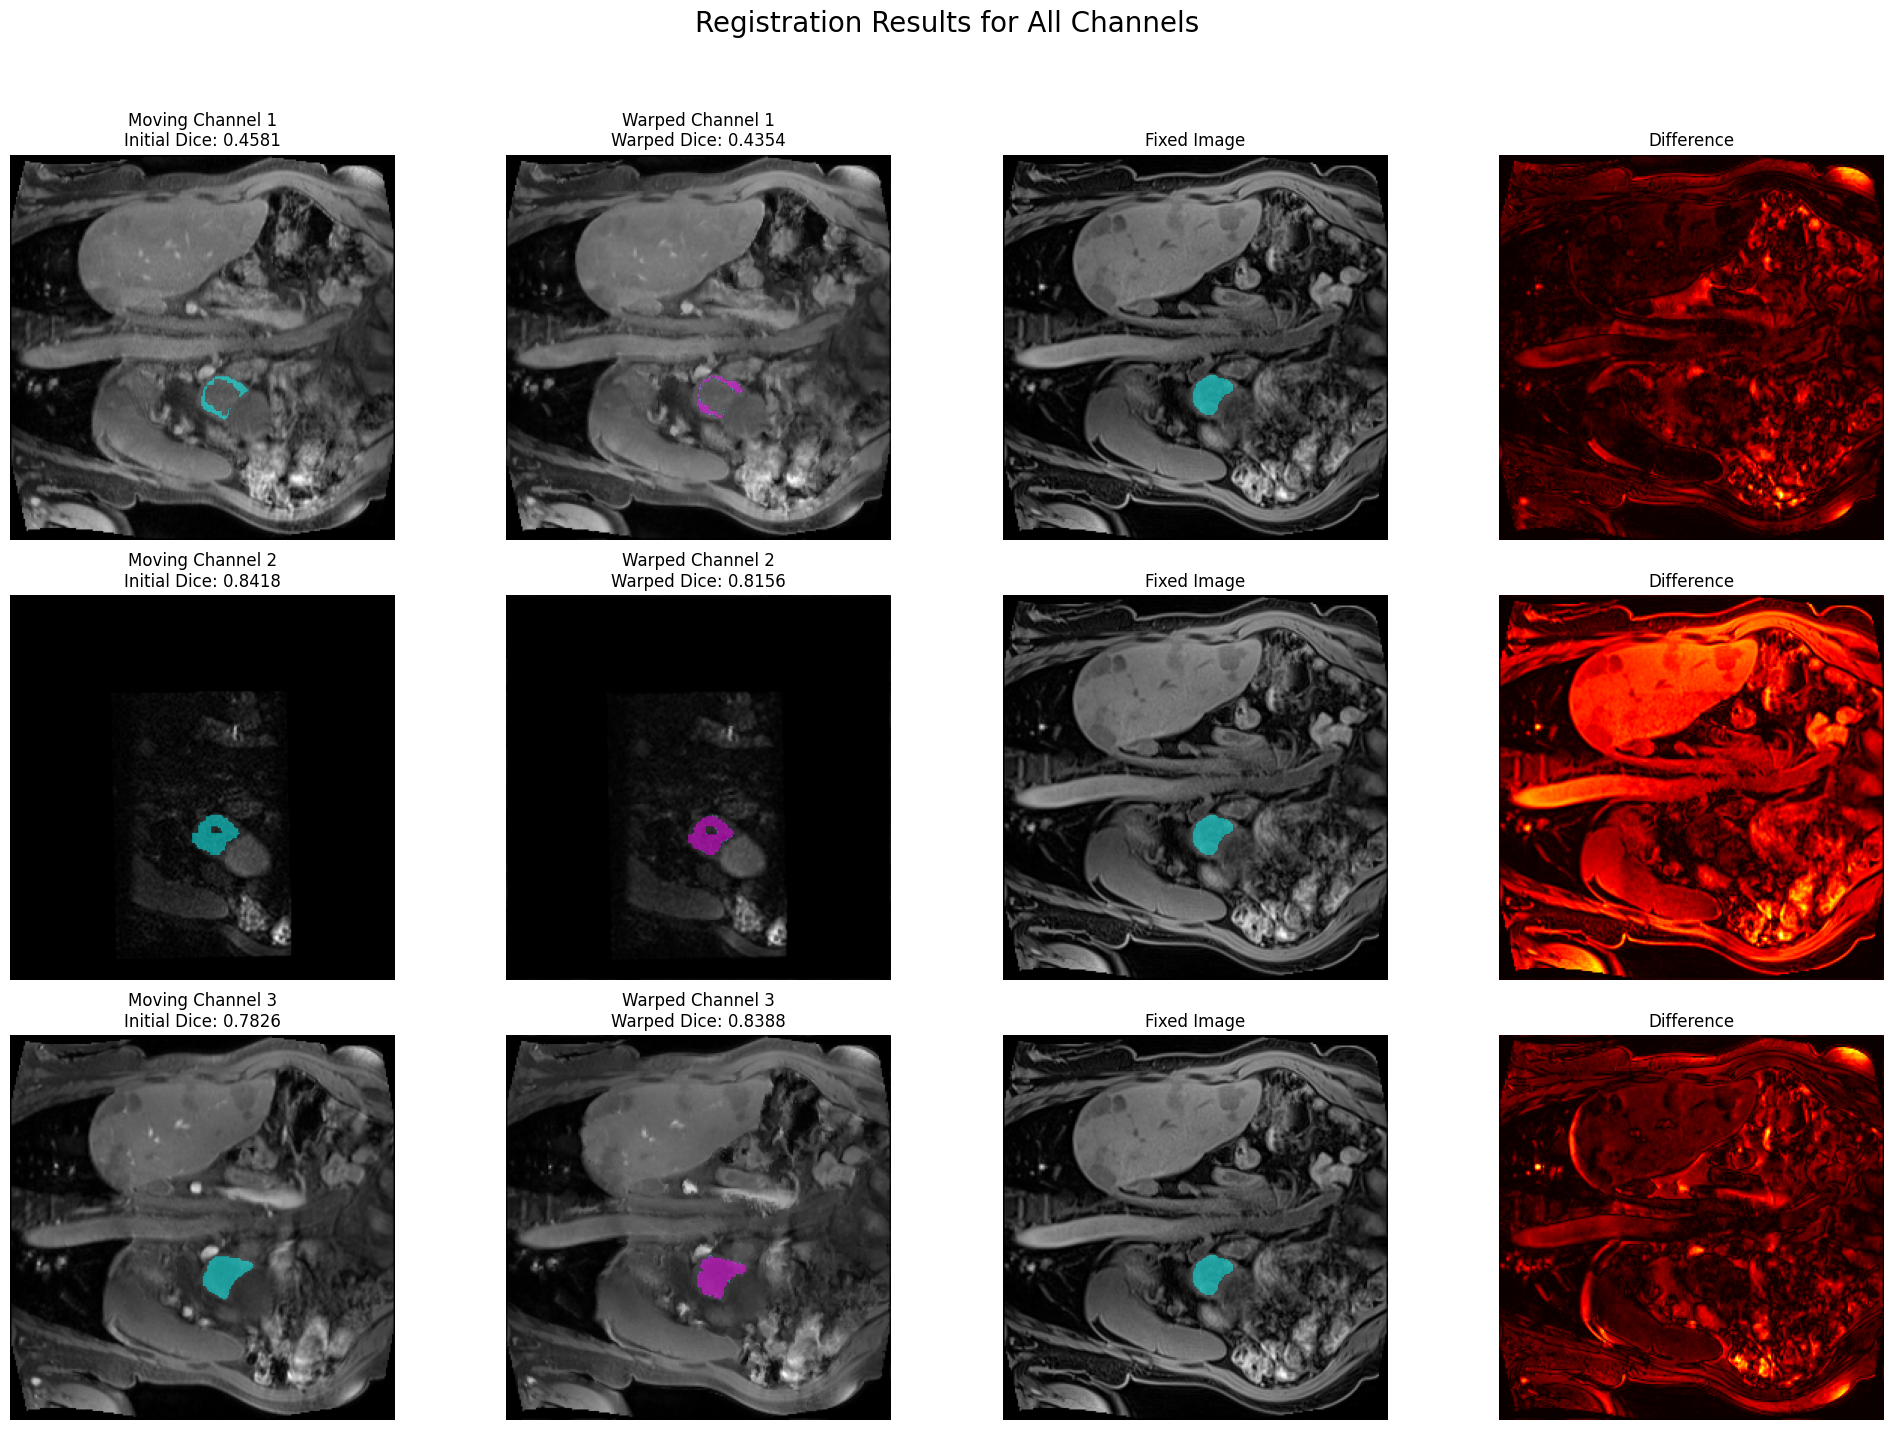

In [26]:
device = torch.device("cpu")
model = RegistrationUNet().to(device)
model.load_state_dict(torch.load("../best_registration_model2.pth", map_location=torch.device('cpu')))
visualize_results(model, data_loader_val, device, num_samples=1)


[Sample 1] Similarity Loss | Unwarped: -0.3794 | Warped: -0.4294 | Perfect: -0.9857


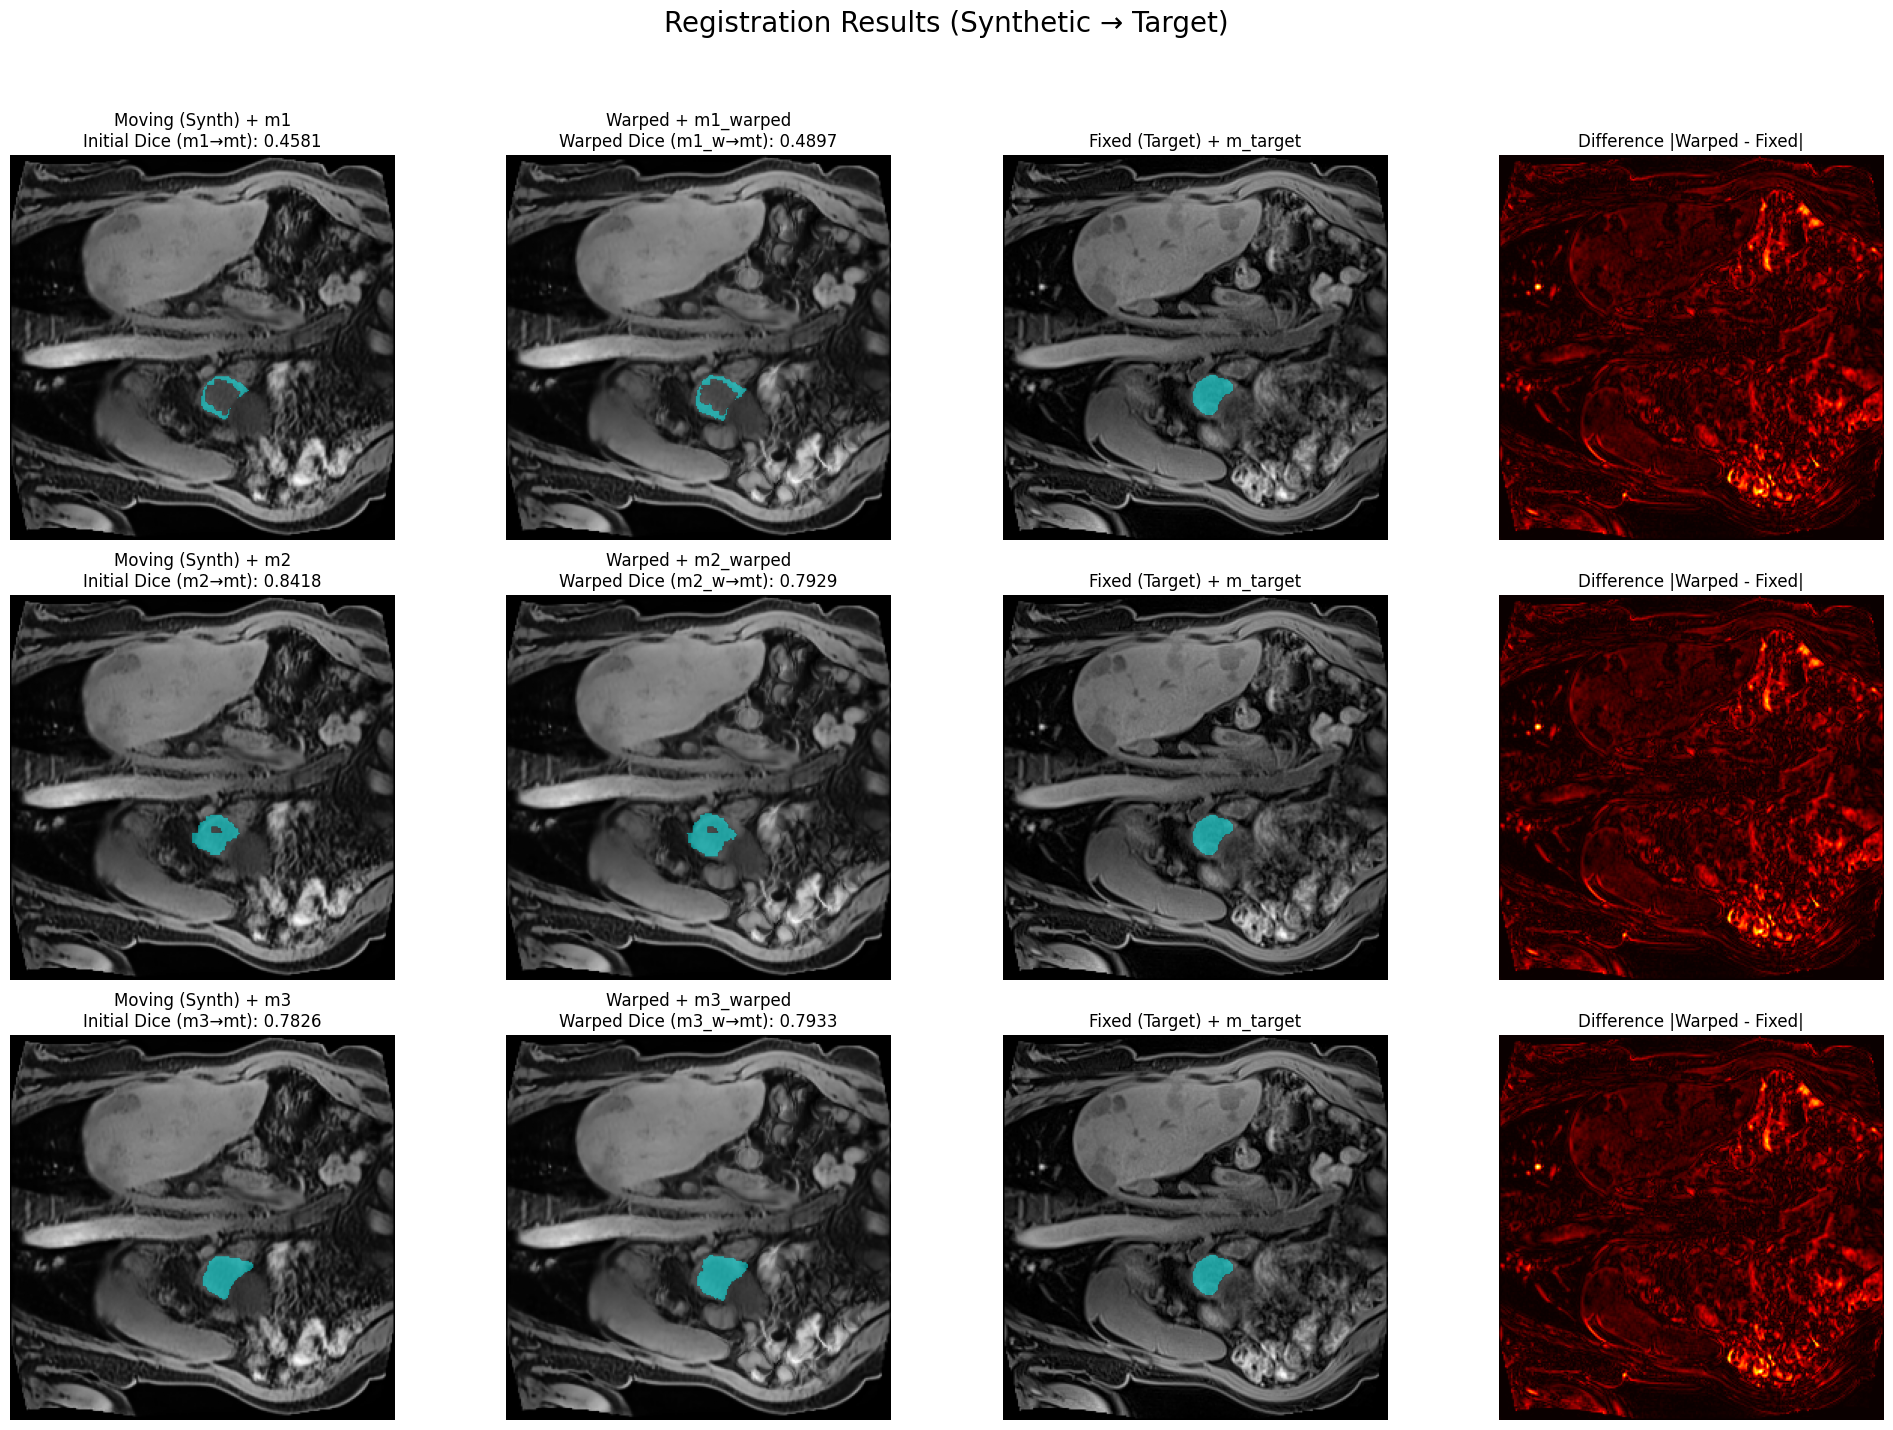

[Sample 1] m1→m_target | Initial Dice: 0.4581 | Warped Dice: 0.4897
[Sample 1] m2→m_target | Initial Dice: 0.8418 | Warped Dice: 0.7929
[Sample 1] m3→m_target | Initial Dice: 0.7826 | Warped Dice: 0.7933
[Sample 2] Similarity Loss | Unwarped: -0.4061 | Warped: -0.4530 | Perfect: -0.9864


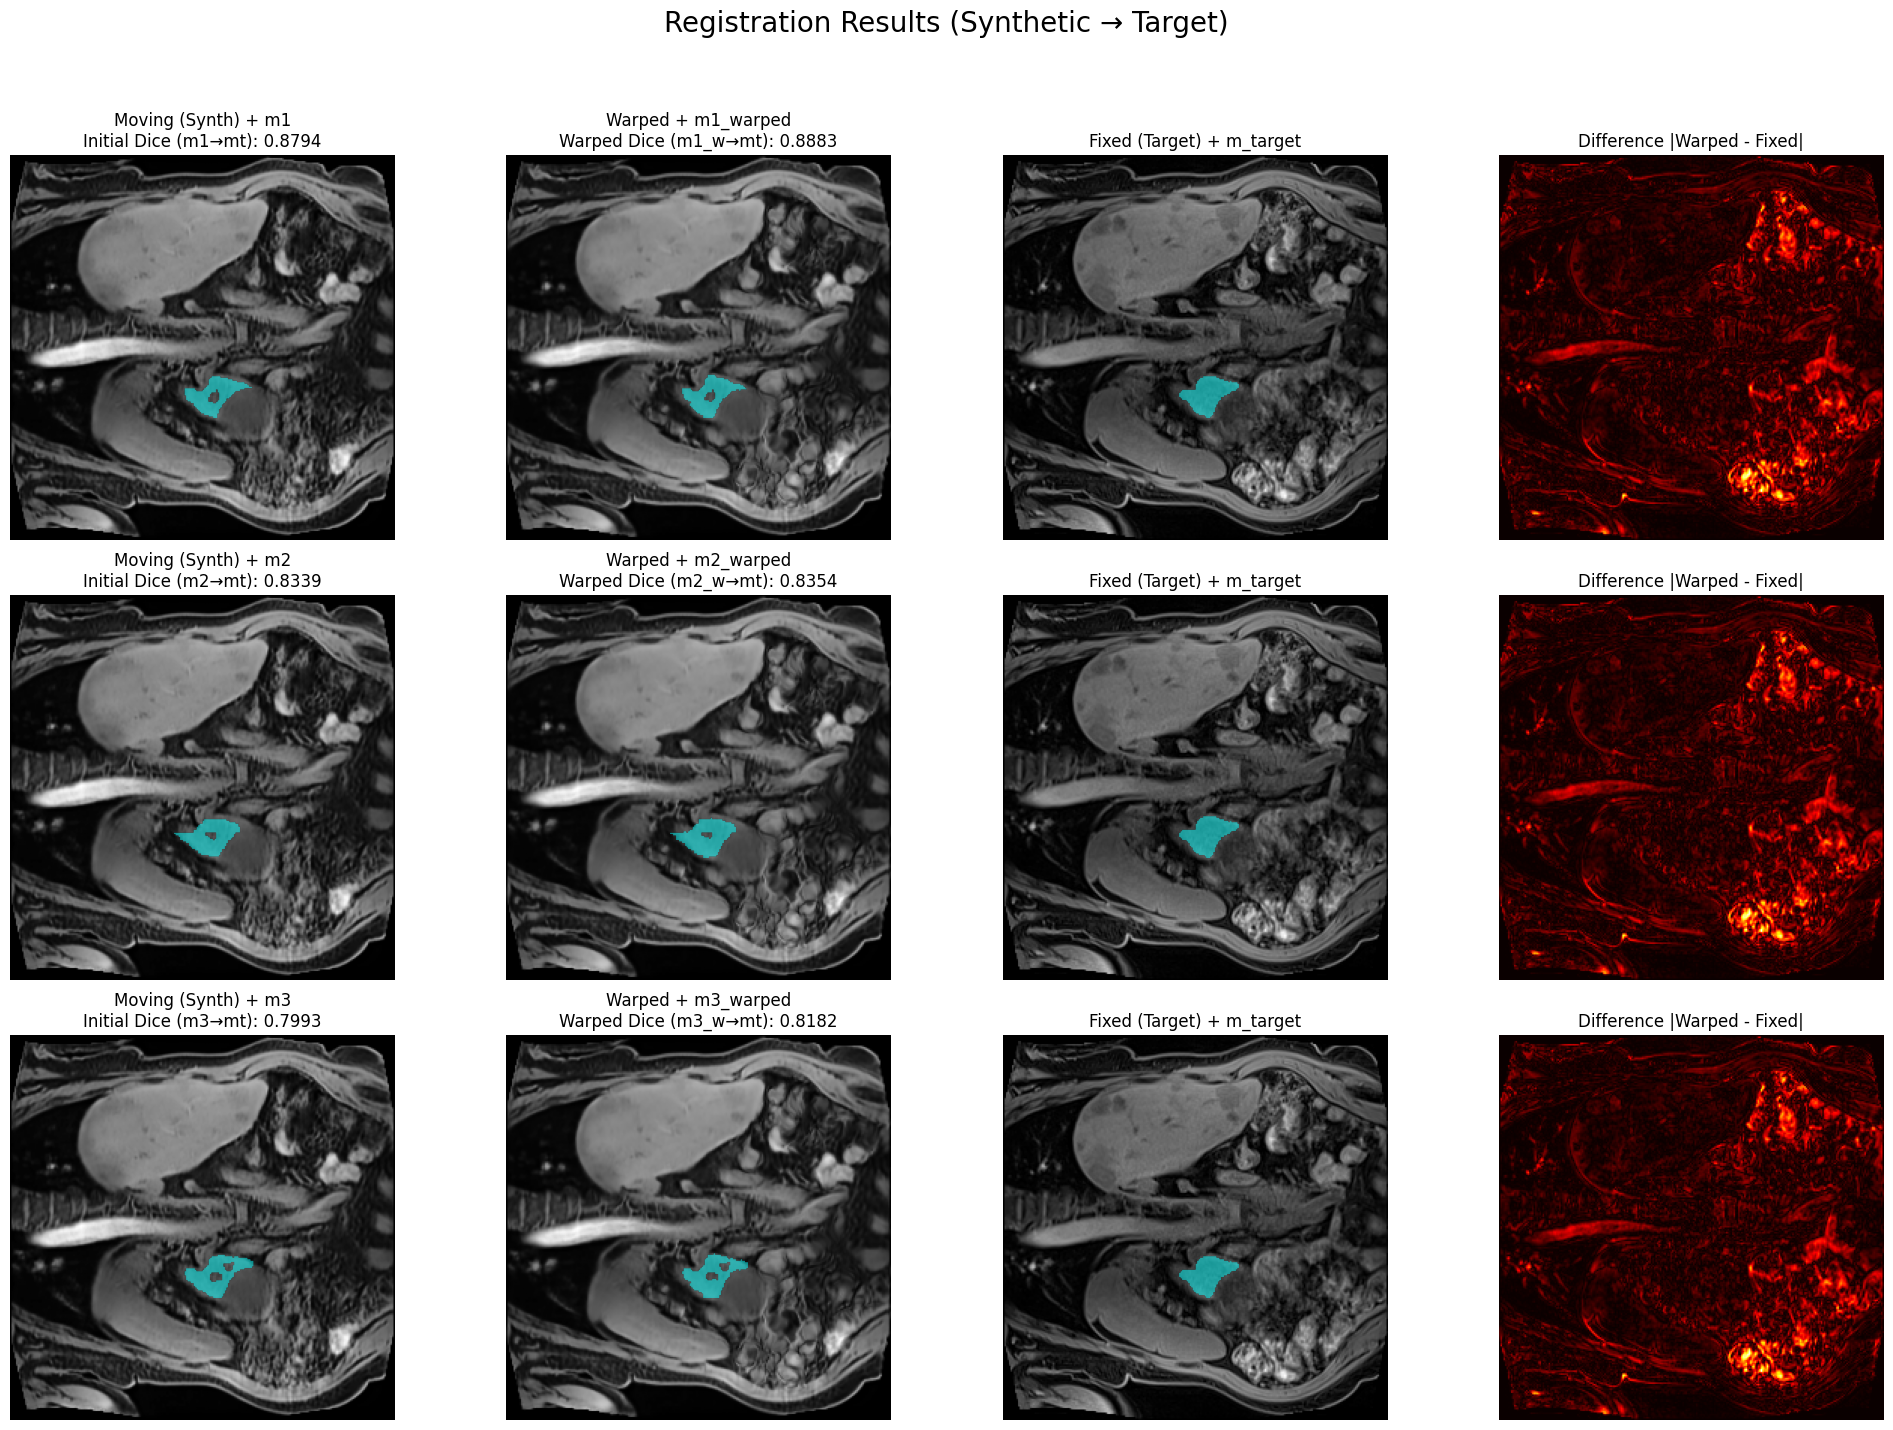

[Sample 2] m1→m_target | Initial Dice: 0.8794 | Warped Dice: 0.8883
[Sample 2] m2→m_target | Initial Dice: 0.8339 | Warped Dice: 0.8354
[Sample 2] m3→m_target | Initial Dice: 0.7993 | Warped Dice: 0.8182
[Sample 3] Similarity Loss | Unwarped: -0.4204 | Warped: -0.4695 | Perfect: -0.9853


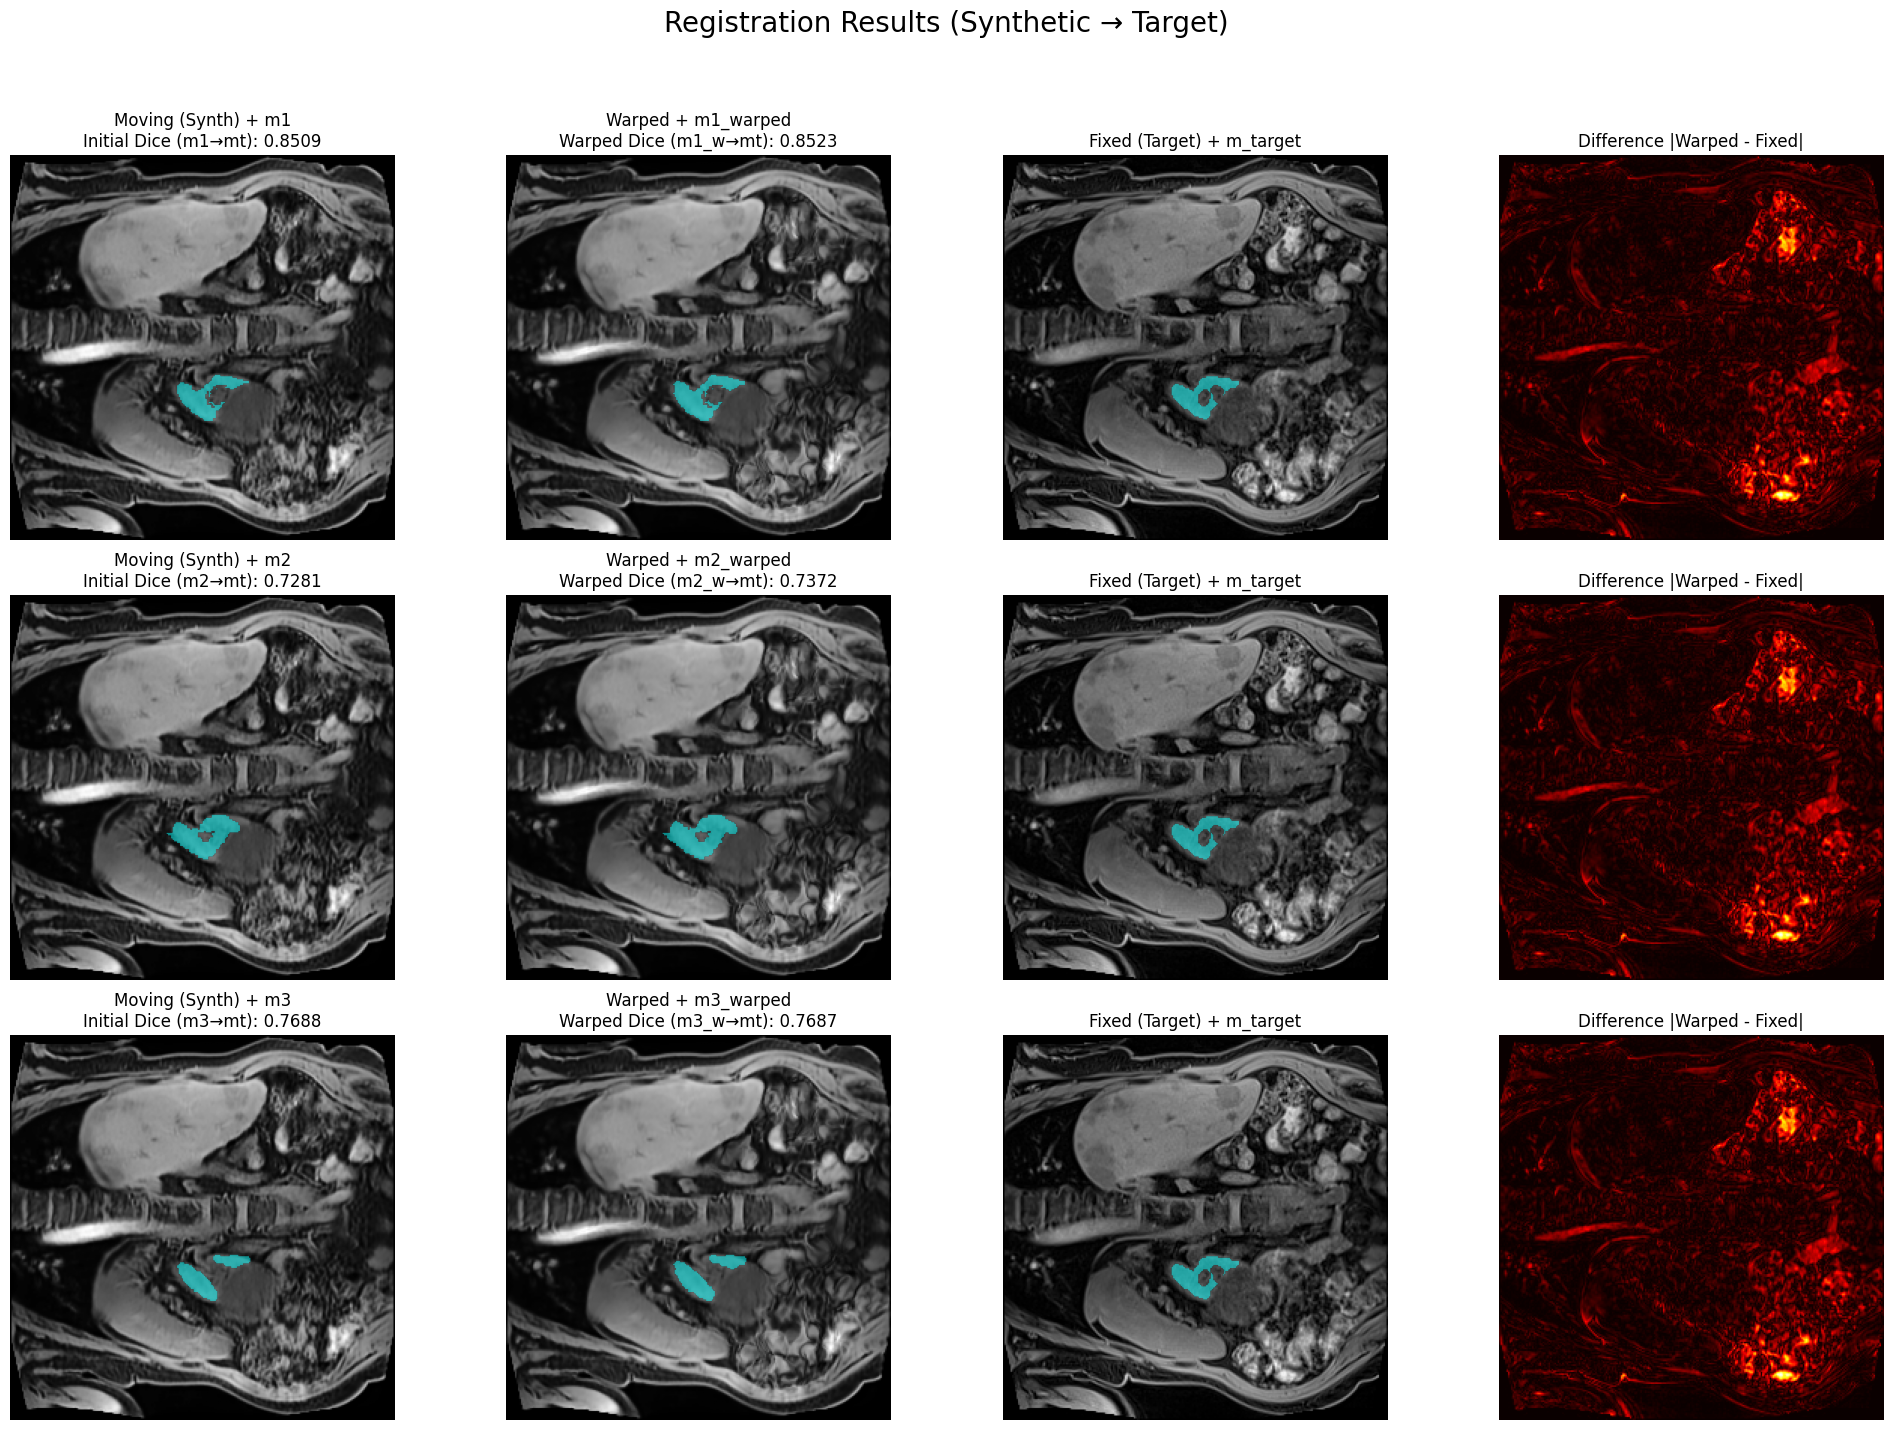

[Sample 3] m1→m_target | Initial Dice: 0.8509 | Warped Dice: 0.8523
[Sample 3] m2→m_target | Initial Dice: 0.7281 | Warped Dice: 0.7372
[Sample 3] m3→m_target | Initial Dice: 0.7688 | Warped Dice: 0.7687


In [87]:
model = RegistrationUNetSingle().to(device)
model.load_state_dict(torch.load("../best_registration_model_synth2target.pth", map_location=torch.device('cpu')))
model.eval()
visualize_results_single(model, data_loader_val_single, device, num_samples=3)

## Losses

In [32]:

class GradientSimilarityLoss(torch.nn.Module):
    """
    Calculates the L2 loss (MSE) on the spatial gradients of the images.
    """
    def __init__(self):
        super().__init__()
        # Define a 2D Sobel filter for X and Y gradients
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        self.register_buffer('sobel_x', sobel_x)
        self.register_buffer('sobel_y', sobel_y)
        self.mse_loss = torch.nn.MSELoss()

    def forward(self, prediction, target):
        # Calculate gradients for the prediction (warped image)
        pred_grad_x = F.conv2d(prediction, self.sobel_x, padding='same')
        pred_grad_y = F.conv2d(prediction, self.sobel_y, padding='same')

        # Calculate gradients for the target (fixed image)
        target_grad_x = F.conv2d(target, self.sobel_x, padding='same')
        target_grad_y = F.conv2d(target, self.sobel_y, padding='same')

        # Calculate the MSE loss between the gradient maps
        return self.mse_loss(pred_grad_x, target_grad_x) + self.mse_loss(pred_grad_y, target_grad_y)


def differentiable_nmi_loss(x, y, num_bins=64, min_val=None, max_val=None, sigma=0.01, eps=1e-8):
    """
    x, y: [B, 1, H, W] float tensors
    Returns: scalar loss = -NMI (maximize NMI ⇔ minimize loss)
    """
    B = x.shape[0]
    x = x.reshape(B, -1)
    y = y.reshape(B, -1)

    # Range
    if min_val is None:
        min_val = torch.min(torch.cat([x, y], dim=1), dim=1, keepdim=True)[0]
    if max_val is None:
        max_val = torch.max(torch.cat([x, y], dim=1), dim=1, keepdim=True)[0]
    # Prevent degenerate range
    span = (max_val - min_val).clamp_min(1e-6)

    # Bin centers (broadcast per-batch)
    bin_ctrs = torch.linspace(0, 1, num_bins, device=x.device).view(1, num_bins, 1)
    x_norm = ((x - min_val) / span).clamp(0, 1)  # [B, N]
    y_norm = ((y - min_val) / span).clamp(0, 1)
    x_norm = x_norm.unsqueeze(1)  # [B, 1, N]
    y_norm = y_norm.unsqueeze(1)

    # Soft-assign to bins with Gaussian kernels
    sigma2 = sigma**2
    pxz = torch.exp(-0.5 * (x_norm - bin_ctrs)**2 / sigma2) + eps  # [B, K, N]
    pyz = torch.exp(-0.5 * (y_norm - bin_ctrs)**2 / sigma2) + eps
    # Normalize responsibilities per sample across bins
    pxz = pxz / pxz.sum(dim=1, keepdim=True)
    pyz = pyz / pyz.sum(dim=1, keepdim=True)

    # Joint histogram via outer product over bins, summed over pixels
    # p_ij ∝ sum_n r_i(x_n) * r_j(y_n)
    joint = torch.bmm(pxz, pyz.transpose(1, 2))  # [B, K, K]
    joint = joint / joint.sum(dim=(1, 2), keepdim=True).clamp_min(eps)

    px = joint.sum(dim=2, keepdim=True)  # [B, K, 1]
    py = joint.sum(dim=1, keepdim=True)  # [B, 1, K]

    # MI = sum p_ij log p_ij/(p_i p_j)
    mi = (joint * (torch.log(joint + eps) - torch.log(px + eps) - torch.log(py + eps))).sum(dim=(1, 2))

    # Entropies
    Hx = -(px.squeeze(2) * torch.log(px.squeeze(2) + eps)).sum(dim=1)
    Hy = -(py.squeeze(1) * torch.log(py.squeeze(1) + eps)).sum(dim=1)

    # Normalized Mutual Information (symmetric)
    nmi = mi / (torch.sqrt(Hx * Hy) + eps)
    loss = -nmi.mean()
    return loss

def box_filter2d(x, k=3):
    """Fast local averaging (separable box) used for SSD smoothing."""
    pad = k // 2
    w = torch.ones((x.shape[1], 1, k, k), device=x.device, dtype=x.dtype) / (k * k)
    return F.conv2d(x, w, padding=pad, groups=x.shape[1])

def mind_descriptor_2d(img, radius=1, dilations=(1,), smooth_k=3, eps=1e-6):
    """
    img: [B, 1, H, W]
    Returns: MIND features [B, C, H, W] with C = len(offsets) * len(dilations)
    """
    B, C, H, W = img.shape
    assert C == 1, "Expect single channel for raw intensities"

    # 4-neighborhood offsets (you can expand to 8 for more robustness)
    base_offsets = [(1,0), (-1,0), (0,1), (0,-1)]
    feats = []

    # Local variance proxy V (stability term)
    mu = box_filter2d(img, k=smooth_k)
    var = box_filter2d((img - mu)**2, k=smooth_k)

    for d in dilations:
        for dy, dx in base_offsets:
            shifted = F.pad(img, (d, d, d, d), mode='reflect')
            shifted = shifted[:, :, d+dy*d: d+dy*d+H, d+dx*d: d+dx*d+W]
            # SSD over a local window
            ssd = box_filter2d((img - shifted)**2, k=smooth_k)
            feat = torch.exp(-ssd / (var + eps))
            feats.append(feat)

    f = torch.cat(feats, dim=1)  # [B, C, H, W]
    # L2 normalize across channels (descriptor scale-invariant)
    f = f / (torch.sqrt((f**2).sum(dim=1, keepdim=True)) + eps)
    return f

def local_ncc_loss(a, b, win=9, eps=1e-5):
    """
    a, b: [B, C, H, W] feature maps
    Returns: scalar loss = 1 - mean(local NCC over channels)
    """
    B, C, H, W = a.shape
    w = torch.ones((C, 1, win, win), device=a.device, dtype=a.dtype)
    pad = win // 2

    def _sum_pool(x):
        return F.conv2d(x, w, padding=pad, groups=C)

    na = _sum_pool(a)
    nb = _sum_pool(b)
    n = win * win

    cross = _sum_pool(a * b) - (na * nb) / n
    var_a = _sum_pool(a * a) - (na * na) / n
    var_b = _sum_pool(b * b) - (nb * nb) / n

    ncc = cross / (torch.sqrt(var_a * var_b + eps))
    # Average over spatial, then channels, then batch
    return (1.0 - ncc.clamp(-1, 1)).mean()


def local_ncc_loss(pred, target, win=9, epsilon=1e-5):
    """
    A numerically stable local NCC loss implementation.
    """
    # Create a 2D average pool filter
    # This is much more efficient than unfolding and summing
    pool = nn.AvgPool2d(kernel_size=win, stride=1, padding=win // 2)

    # Mean of prediction and target patches
    mu_pred = pool(pred)
    mu_target = pool(target)

    # Variance of prediction and target patches
    # E[X^2] - (E[X])^2
    var_pred = pool(pred**2) - mu_pred**2
    var_target = pool(target**2) - mu_target**2

    # Cross-correlation
    # E[XY] - E[X]E[Y]
    cross_corr = pool(pred * target) - mu_pred * mu_target

    # The NCC formula with the stabilizing epsilon
    # The epsilon is added to the variance term before the sqrt
    # to prevent division by zero and sqrt of negative numbers.
    ncc_numerator = cross_corr
    ncc_denominator = torch.sqrt(var_pred * var_target + epsilon)
    
    ncc = ncc_numerator / ncc_denominator

    # NCC is a similarity measure (higher is better), so for a loss, we use 1 - ncc
    # We take the mean over the spatial dimensions and batch
    return 1 - torch.mean(ncc)



class SmallEncoder2D(nn.Module):
    def __init__(self, in_ch=1, feat_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 16, 3, padding=1), nn.InstanceNorm2d(16), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(16, 32, 3, padding=1), nn.InstanceNorm2d(32), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, feat_ch, 3, padding=1), nn.InstanceNorm2d(feat_ch)
        )
    def forward(self, x):
        f = self.net(x)
        # channel-wise L2 norm for stability
        f = f / (torch.sqrt((f**2).sum(dim=1, keepdim=True)) + 1e-6)
        return f

# Example similarity on embeddings:
def feature_space_ncc_loss(encoder, x, y, win=9):
    fx = encoder(x)
    fy = encoder(y)
    return local_ncc_loss(fx, fy, win=win)


#### ACTUAL losses

LNCC_loss = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2)
dice_metric = DiceMetric(include_background=True, reduction="mean")
MI_loss = monai.losses.GlobalMutualInformationLoss()
SSIM_loss = monai.losses.ssim_loss.SSIMLoss(spatial_dims=2)
Perceptual_loss = monai.losses.PerceptualLoss(spatial_dims=2, pretrained=True)
Juke_loss = monai.losses.JukeboxLoss(spatial_dims=2)

gradient_loss = GradientSimilarityLoss()

def local_ncc_loss_complete(x1, x2):
    mind_pred   = mind_descriptor_2d(x1, dilations=(1,2), smooth_k=5)
    mind_target = mind_descriptor_2d(x2, dilations=(1,2), smooth_k=5)
    mind_ncc_loss_val = local_ncc_loss(mind_pred, mind_target, win=9)
    return mind_ncc_loss_val


def feature_space_ncc_loss_complete(x1,x2):
    encoder = SmallEncoder2D(in_ch=1, feat_ch=32)
    feat_ncc_loss_val = feature_space_ncc_loss(encoder, x1, x2, win=9)
    return feat_ncc_loss_val

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.


In [38]:
loss_dictionary = {
    "LNCC": LNCC_loss,
    "MI": MI_loss,
    "SSIM": SSIM_loss,
    "Perceptual": Perceptual_loss,
    "Juke": Juke_loss,
    "GradientSim": gradient_loss,
    "LocalNCC_MIND": local_ncc_loss_complete,
    "FeatureNCC": feature_space_ncc_loss_complete
}

In [39]:
for iteration, (x1, x2, x3, x4, m1, m2, m3, m4) in enumerate(data_loader):
    if iteration >= 10:
        break

In [40]:
for loss_name, loss_fn in loss_dictionary.items():
    print(f"Calculating {loss_name} loss:")
    loss_value_same = loss_fn(x4, x4).item()
    loss_value_diff = loss_fn(x1, x4).item()
    print(f"  {loss_name} Loss (Same): {loss_value_same:.6f}")
    print(f"  {loss_name} Loss (Diff): {loss_value_diff:.6f}\n")

Calculating LNCC loss:
  LNCC Loss (Same): -0.979029
  LNCC Loss (Diff): -0.334187

Calculating MI loss:
  MI Loss (Same): -0.051862
  MI Loss (Diff): -0.001401

Calculating SSIM loss:
  SSIM Loss (Same): 0.000000
  SSIM Loss (Diff): 0.733433

Calculating Perceptual loss:
  Perceptual Loss (Same): 0.000000
  Perceptual Loss (Diff): 0.304499

Calculating Juke loss:
  Juke Loss (Same): 0.000000
  Juke Loss (Diff): 0.053032

Calculating GradientSim loss:
  GradientSim Loss (Same): 0.000000
  GradientSim Loss (Diff): 1.372921

Calculating LocalNCC_MIND loss:
  LocalNCC_MIND Loss (Same): 0.153376
  LocalNCC_MIND Loss (Diff): 0.618078

Calculating FeatureNCC loss:
  FeatureNCC Loss (Same): 0.101331
  FeatureNCC Loss (Diff): 0.857043



#### Calculation

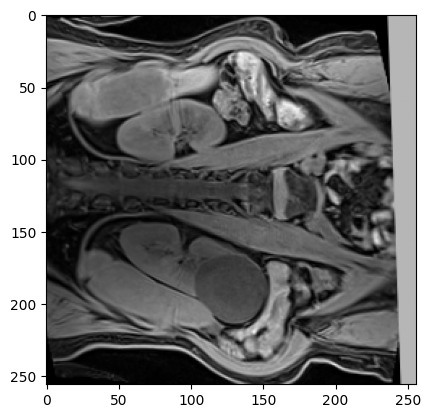

In [41]:
def small_random_affine(
    x: torch.Tensor,
    mask: torch.Tensor = None,
    degrees: float = 2.0,          # max |rotation| in degrees
    translate: float = 0.02,       # max shift as a fraction of width/height
    scale: float = 0.02,           # scale jitter -> 1±scale
    shear: float = 2.0,            # max |shear| in degrees (x and y)
    mode: str = "bilinear",
    padding_mode: str = "zeros",
    align_corners: bool = False,
):
    """
    Apply a small random affine transform to a batch of grayscale images.

    Args:
        x: Tensor [N, 1, H, W].
        degrees, translate, scale, shear: magnitudes for random sampling.
        mode, padding_mode, align_corners: passed to grid_sample.

    Returns:
        y: transformed images [N, 1, H, W]
        params: dict of the sampled parameters (per-image tensors)
    """
    assert x.ndim == 4 and x.size(1) == 1, "x must be [N,1,H,W]"
    N, _, H, W = x.shape
    device, dtype = x.device, x.dtype

    # sample random params per image
    rot = (torch.rand(N, device=device) * 2 - 1) * degrees
    tx = (torch.rand(N, device=device) * 2 - 1) * translate  # fraction of width
    ty = (torch.rand(N, device=device) * 2 - 1) * translate  # fraction of height
    sx = 1.0 + (torch.rand(N, device=device) * 2 - 1) * scale
    sy = 1.0 + (torch.rand(N, device=device) * 2 - 1) * scale
    shx = (torch.rand(N, device=device) * 2 - 1) * shear
    shy = (torch.rand(N, device=device) * 2 - 1) * shear

    # convert to radians
    rot_r = rot * math.pi / 180.0
    shx_r = shx * math.pi / 180.0
    shy_r = shy * math.pi / 180.0

    # build 2x3 affine matrices per image.
    # We compose in the order: Scale -> Shear -> Rotate -> Translate.
    # All ops are in normalized grid coords ([-1,1]).
    thetas = []
    for i in range(N):
        c = torch.cos(rot_r[i])
        s = torch.sin(rot_r[i])

        # scale
        S = torch.tensor([[sx[i],     0.0, 0.0],
                          [0.0,     sy[i], 0.0]], device=device, dtype=dtype)

        # shear (x then y)
        Sh = torch.tensor([[1.0, torch.tan(shx_r[i]), 0.0],
                           [torch.tan(shy_r[i]), 1.0, 0.0]], device=device, dtype=dtype)

        # rotation
        R = torch.tensor([[ c, -s, 0.0],
                          [ s,  c, 0.0]], device=device, dtype=dtype)

        # translation in normalized coords: fraction -> [-1,1] shift
        # tx, ty are fractions of width/height; multiply by 2 to convert to [-1,1] units
        T = torch.tensor([[1.0, 0.0, 2.0 * tx[i]],
                          [0.0, 1.0, 2.0 * ty[i]]], device=device, dtype=dtype)

        # compose: A = T @ R @ Sh @ S  (2x3 @ 2x3* -> keep as 3x3 with hom coords)
        def to33(M):
            return torch.tensor([[M[0,0], M[0,1], M[0,2]],
                                 [M[1,0], M[1,1], M[1,2]],
                                 [0.0,    0.0,    1.0]], device=device, dtype=dtype)

        A = to33(T) @ to33(R) @ to33(Sh) @ to33(S)
        theta = A[:2, :]  # 2x3
        thetas.append(theta)

    theta = torch.stack(thetas, dim=0)  # [N,2,3]

    grid = F.affine_grid(theta, size=x.shape, align_corners=align_corners)
    y = F.grid_sample(x, grid, mode=mode, padding_mode=padding_mode, align_corners=align_corners)

    # apply same transform to mask if given
    if mask is not None:
        y_mask = F.grid_sample(mask, grid, mode="nearest", padding_mode=padding_mode, align_corners=align_corners)
        y = (y, y_mask)

    params = {
        "degrees": rot,
        "translate_x_frac": tx,
        "translate_y_frac": ty,
        "scale_x": sx,
        "scale_y": sy,
        "shear_x_deg": shx,
        "shear_y_deg": shy,
    }
    return y, params


x4_transformed = small_random_affine(x4, mask=None, degrees=0.0, translate=0.05, scale=0.05, shear=5.0)[0]

plt.imshow(x4_transformed[0,0].cpu(), cmap='gray')


In [47]:
from scipy.stats import pearsonr

def calculate_loss_fct_values_random(loss_dictionary, max_samples):
    """
    Calculates various losses and their corresponding Dice scores,
    stores them in a DataFrame, and computes their correlation.
    """
    print("Starting analysis...")

    results_list = []

    # Iterate over your dataset
    for iteration in range(max_samples):
            
        random_img1 = torch.randn(1, 1, 256, 256)
        random_img2 = torch.randn(1, 1, 256, 256)


        moving = "None"
        dice_score = 0
            
        # Calculate each loss for the current image pair
        for loss_name, loss_fn in loss_dictionary.items():
            loss_value = loss_fn(random_img1, random_img2).item()

            # check if nan and if so skip
            if math.isnan(loss_value):
                print(f"Warning: {loss_name} returned NaN for in batch {iteration}. Skipping.")
                continue
            
            # Store the results
            results_list.append({
                "Batch": iteration,
                "Moving Image": moving,
                "Loss Name": loss_name,
                "Loss Value": loss_value,
                "Dice Score": dice_score,
                "Type": "Random"
            })

    # Create a Pandas DataFrame from the results
    df = pd.DataFrame(results_list)
    return df

def calculate_loss_fct_values_same(data_loader, loss_dictionary, max_samples):
    """
    Calculates various losses and their corresponding Dice scores,
    stores them in a DataFrame, and computes their correlation.
    """
    print("Starting analysis...")

    results_list = []

    # Iterate over your dataset
    for iteration, (x1, x2, x3, x4, m1, m2, m3, m4) in enumerate(data_loader):
        if iteration % 10 == 0:
            print(f"Processing batch {iteration}/{len(data_loader)}...")
        if iteration >= max_samples:
            break
            
        # Calculate the Dice score for the current pair against the target
        moving = "Dixon"
        dice_score = float(dice_metric(m4, m4))
        
        # Calculate each loss for the current image pair
        for loss_name, loss_fn in loss_dictionary.items():
            loss_value = loss_fn(x4, x4).item()

            # check if nan and if so skip
            if math.isnan(loss_value):
                print(f"Warning: {loss_name} returned NaN for in batch {iteration}. Skipping.")
                continue
            
            # Store the results
            results_list.append({
                "Batch": iteration,
                "Moving Image": moving,
                "Loss Name": loss_name,
                "Loss Value": loss_value,
                "Dice Score": dice_score,
                "Type": "Same"
            })

    # Create a Pandas DataFrame from the results
    df = pd.DataFrame(results_list)
    return df

def calculate_loss_fct_values_affine(data_loader, loss_dictionary, max_samples):
    """
    Calculates various losses and their corresponding Dice scores,
    stores them in a DataFrame, and computes their correlation.
    """
    print("Starting analysis...")

    results_list = []

    # Iterate over your dataset
    for iteration, (x1, x2, x3, x4, m1, m2, m3, m4) in enumerate(data_loader):
        if iteration % 10 == 0:
            print(f"Processing batch {iteration}/{len(data_loader)}...")
        if iteration >= max_samples:
            break
            
        # Calculate the Dice score for the current pair against the target
        moving = "Dixon"
        dice_score = float(dice_metric(m4, m4))
        
        # Calculate each loss for the current image pair
        for loss_name, loss_fn in loss_dictionary.items():
            x4_affine, m4_affine  = small_random_affine(x4, m4, degrees=0.0, translate=0.05, scale=0.05, shear=5.0)[0]
            loss_value = loss_fn(x4, x4_affine).item()

            # check if nan and if so skip
            if math.isnan(loss_value):
                print(f"Warning: {loss_name} returned NaN for in batch {iteration}. Skipping.")
                continue
            
            # Store the results
            results_list.append({
                "Batch": iteration,
                "Moving Image": moving,
                "Loss Name": loss_name,
                "Loss Value": loss_value,
                "Dice Score": dice_score,
                "Type": "Affine"
            })

    # Create a Pandas DataFrame from the results
    df = pd.DataFrame(results_list)
    return df



def calculate_loss_fct_values(data_loader, loss_dictionary, max_samples):
    """
    Calculates various losses and their corresponding Dice scores,
    stores them in a DataFrame, and computes their correlation.
    """
    print("Starting analysis...")

    results_list = []

    # Iterate over your dataset
    for iteration, (x1, x2, x3, x4, m1, m2, m3, m4) in enumerate(data_loader):
        if iteration % 10 == 0:
            print(f"Processing batch {iteration}/{len(data_loader)}...")
        if iteration >= max_samples:
            break
            
        # Define the pairs of images and masks to process
        image_mask_pairs = [
            ("BOLD", x1, m1),
            ("Diffusion", x2, m2),
            ("T1", x3, m3)
        ]

        for pair_name, image, mask in image_mask_pairs:
            # Calculate the Dice score for the current pair against the target
            moving = pair_name
            dice_score = float(dice_metric(mask, m4))
            
            # Calculate each loss for the current image pair
            for loss_name, loss_fn in loss_dictionary.items():
                loss_value = loss_fn(image, x4).item()

                # check if nan and if so skip
                if math.isnan(loss_value):
                    print(f"Warning: {loss_name} returned NaN for {pair_name} in batch {iteration}. Skipping.")
                    continue
                
                # Store the results
                results_list.append({
                    "Batch": iteration,
                    "Moving Image": moving,
                    "Loss Name": loss_name,
                    "Loss Value": loss_value,
                    "Dice Score": dice_score,
                    "Type": "Real"
                })

    # Create a Pandas DataFrame from the results
    df = pd.DataFrame(results_list)
    return df


def analyze_loss_dice_correlation(data_loader, loss_dictionary, max_samples=50):
    
    df = calculate_loss_fct_values(data_loader, loss_dictionary, max_samples)
    # --- Correlation Analysis ---
    print("\n--- Correlation Analysis (Loss vs. Dice Score) ---")
    
    correlation_results = {}

    # Group by loss name and calculate Pearson correlation
    for loss_name, group in df.groupby("Loss Name"):
        # pearsonr returns (correlation_coefficient, p_value)
        corr, p_value = pearsonr(group["Loss Value"], group["Dice Score"])
        correlation_results[loss_name] = {"Correlation": corr, "P-Value": p_value}

    # Convert correlation results to a DataFrame for nice printing
    corr_df = pd.DataFrame.from_dict(correlation_results, orient='index')
    corr_df = corr_df.sort_values(by="Correlation", ascending=False) # Sort by correlation
    
    print(corr_df)
    
    print("\nAnalysis complete.")
    return df, corr_df


#### Loss dictionary

In [ ]:
results_df_random = calculate_loss_fct_values_random(loss_dictionary, max_samples=20)
results_df_same = calculate_loss_fct_values_same(data_loader_val, loss_dictionary, max_samples=20)
results_df_affine = calculate_loss_fct_values_affine(data_loader_val, loss_dictionary, max_samples=20)
results_df_real = calculate_loss_fct_values(data_loader_val, loss_dictionary, max_samples=20)

Starting analysis...
Starting analysis...
Processing batch 0/71...
Processing batch 10/71...
Processing batch 20/71...
Starting analysis...
Processing batch 0/71...
Processing batch 10/71...
Processing batch 20/71...
Starting analysis...
Processing batch 0/71...
Processing batch 10/71...


In [ ]:
# combine them
results_df = pd.concat([results_df_random, results_df_same, results_df_affine, results_df_real], ignore_index=True)

In [ ]:
results_df.groupby([ "Loss Name", "Type"])[["Loss Value", "Dice Score"]].mean()

Loss Value  Dice Score
Loss Name     Type                          
FeatureNCC    Affine    0.980668    1.000000
              Random    0.998167    0.000000
              Real      0.775559    0.816423
              Same      0.084872    1.000000
GradientSim   Affine    1.824813    1.000000
              Random   47.771646    0.000000
              Real      0.821410    0.816423
              Same      0.000000    1.000000
Juke          Affine    0.035337    1.000000
              Random    0.427958    0.000000
              Real      0.086319    0.816423
              Same      0.000000    1.000000
LNCC          Affine   -0.263857    1.000000
              Random   -0.125589    0.000000
              Real     -0.240184    0.816423
              Same     -0.981564    1.000000
LocalNCC_MIND Affine    0.923429    1.000000
              Random    0.959944    0.000000
              Real      0.743656    0.816423
              Same      0.114364    1.000000
MI            Affine   -0.003911    1.000000
              Random   -0.001054    0.000000
              Real     -0.003464    0.816423
              Same     -0.072179    1.000000
Perceptual    Affine    0.246145    1.000000
              Random    0.155174    0.000000
              Real      0.461037    0.816423
              Same      0.000000    1.000000
SSIM          Affine    0.894626    1.000000
              Random    0.994093    0.000000
              Real      0.705374    0.816423
              Same      0.000000    1.000000

In [23]:
results_df[results_df["Dice Score"]>0.9][["Loss Name", "Loss Value"]].groupby("Loss Name").mean()

,Loss Value
Loss Name,


#### LNCC dictionary

In [83]:
LNCC_kernel3 = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="rectangular", kernel_size=3)
LNCC_kernel15 = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="rectangular", kernel_size=15)
LNCC_kernel7 = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="rectangular", kernel_size=7)
LNCC_kernel29 = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="rectangular", kernel_size=29)
LNCC_kernel3_gaussian = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="gaussian", kernel_size=3)
LNCC_kernel15_gaussian = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="gaussian", kernel_size=15)
LNCC_kernel7_gaussian = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="gaussian", kernel_size=7)
LNCC_kernel29_gaussian = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="gaussian", kernel_size=29)
LNCC_kernel51 = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="rectangular", kernel_size=51)
LNCC_kernel_75 = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="rectangular", kernel_size=75)
LNCC_kernel_91 = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="rectangular", kernel_size=91)
LNCC_kernel_100 = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="rectangular", kernel_size=101)
LNCC_kernel_150 = monai.losses.LocalNormalizedCrossCorrelationLoss(spatial_dims=2, kernel_type="rectangular", kernel_size=151)


LNCC_dictionary = {
    "LNCC_3": LNCC_kernel3,
    "LNCC_7": LNCC_kernel7,
    "LNCC_15": LNCC_kernel15,
    "LNCC_29": LNCC_kernel29,
    "LNCC_51": LNCC_kernel51,
    "LNCC_75": LNCC_kernel_75,
    "LNCC_90": LNCC_kernel_91,
    "LNCC_100": LNCC_kernel_100,
    "LNCC_150": LNCC_kernel_150,
    "LNCC_3_gaussian": LNCC_kernel3_gaussian,
}

In [84]:
results_df_random = calculate_loss_fct_values_random(LNCC_dictionary, max_samples=20)
results_df_same = calculate_loss_fct_values_same(data_loader_val, LNCC_dictionary, max_samples=20)
results_df_affine = calculate_loss_fct_values_affine(data_loader_val, LNCC_dictionary, max_samples=20)
results_df_real = calculate_loss_fct_values(data_loader_val, LNCC_dictionary, max_samples=20)

Starting analysis...
Starting analysis...
Processing batch 0/71...
Processing batch 10/71...
Processing batch 20/71...
Starting analysis...
Processing batch 0/71...
Processing batch 10/71...
Processing batch 20/71...
Starting analysis...
Processing batch 0/71...
Processing batch 10/71...
Processing batch 20/71...


In [85]:
results_df = pd.concat([results_df_random, results_df_same, results_df_affine, results_df_real], ignore_index=True)
results_df["Loss Value"] = results_df["Loss Value"].apply(lambda x: np.round(x,3))

In [86]:
results_df.groupby([ "Loss Name", "Type"])[["Loss Value", "Dice Score"]].mean()

Loss Value  Dice Score
Loss Name       Type                          
LNCC_100        Affine   -0.312450    1.000000
                Random    0.000000    0.000000
                Real     -0.533417    0.816423
                Same     -1.000000    1.000000
LNCC_15         Affine   -0.137450    1.000000
                Random   -0.004700    0.000000
                Real     -0.319067    0.816423
                Same     -1.000000    1.000000
LNCC_150        Affine   -0.436100    1.000000
                Random    0.000000    0.000000
                Real     -0.616083    0.816423
                Same     -1.000000    1.000000
LNCC_29         Affine   -0.164900    1.000000
                Random   -0.001050    0.000000
                Real     -0.378050    0.816423
                Same     -1.000000    1.000000
LNCC_3          Affine   -0.253000    1.000000
                Random   -0.125950    0.000000
                Real     -0.240217    0.816423
                Same     -0.981650    1.000000
LNCC_3_gaussian Affine   -0.256650    1.000000
                Random   -0.134000    0.000000
                Real     -0.234750    0.816423
                Same     -0.979050    1.000000
LNCC_51         Affine   -0.232750    1.000000
                Random   -0.000300    0.000000
                Real     -0.437467    0.816423
                Same     -1.000000    1.000000
LNCC_7          Affine   -0.162400    1.000000
                Random   -0.021100    0.000000
                Real     -0.253933    0.816423
                Same     -0.997350    1.000000
LNCC_75         Affine   -0.273650    1.000000
                Random    0.000000    0.000000
                Real     -0.486117    0.816423
                Same     -1.000000    1.000000
LNCC_90         Affine   -0.310750    1.000000
                Random    0.000000    0.000000
                Real     -0.515700    0.816423
                Same     -1.000000    1.000000

In [69]:
results_df

,Batch,Moving Image,Loss Name,Loss Value,Dice Score,Type
0,0,None,LNCC_3,-0.12,0.000000,Random
1,0,None,LNCC_15,-0.00,0.000000,Random
2,0,None,LNCC_7,-0.02,0.000000,Random
3,0,None,LNCC_29,-0.00,0.000000,Random
4,0,None,LNCC_3_gaussian,-0.13,0.000000,Random
...,...,...,...,...,...,...
835,19,T1,LNCC_7,-0.44,0.899913,Real
836,19,T1,LNCC_29,-0.59,0.899913,Real
837,19,T1,LNCC_3_gaussian,-0.39,0.899913,Real
838,19,T1,LNCC_15_gaussian,-0.00,0.899913,Real
